# Shock finding in a moving mesh - RICH radiation hydrodynamics
[Schaal & Springel, 2014](https://arxiv.org/abs/1407.4117), [Schaal et al, 2016](https://arxiv.org/abs/1604.07401)

## Step 1: flag the shock zones
According to these three criteria
$$
\begin{gather}
\partial_i v^i < 0
\\
\partial^i T \partial_i p > 0
\\
\Delta \log T \geq \log \left. \frac{T_2}{T_1} \right|_{\mathcal{M}_\mathrm{min}}
\\
\Delta \log p \geq \log \left. \frac{p_2}{p_1} \right|_{\mathcal{M}_\mathrm{min}}
\end{gather}
$$

In [1]:
%load_ext autoreload
%autoreload 2
import os

import numpy as np
import h5py
import matplotlib.pyplot as plt
import unyt as u
import math

import richio
import nb, dev

In [2]:
snap_dir = '/home/hey4/rich_tde/data/raw/SedovDissipationGrad'
!ls $snap_dir

sedov_0.h5   sedov_100.h5   sedov_50.h5   sedov_final.h5
sedov_0.vtu  sedov_100.vtu  sedov_50.vtu  sedov_final.vtu


In [3]:
snap = richio.load(os.path.join(snap_dir, 'sedov_100.h5'))

In [4]:
snap.info()

                                     RICH SNAPSHOT INFORMATION                                      

Snapshot Details                        
----------------------------------------------------------------------------------------------------
  Path                      : /home/hey4/rich_tde/data/raw/SedovDissipationGrad/sedov_100.h5
  Snapshot Number           : -1
  Time                      : [0.0042907] code_time
  Box size                  : [-1. -1. -1.  1.  1.  1.] code_length
  Cycle                     : [100.] dimensionless
  Number of Cells           : 100,000
  Number of Ranks           : 1

Available Fields                         [Unit System: RICH]
----------------------------------------------------------------------------------------------------
Field           Unit                                     Aliases
----------------------------------------------------------------------------------------------------
Box             code_length                              box

/zfsstore/user/hey4/rich_tde/richio/richio/units.py:126: UserWarning: 'Eg_0' is in the data output but not used in the simulation.
  warnings.warn(f"'{key}' is in the data output but not used in the simulation.")


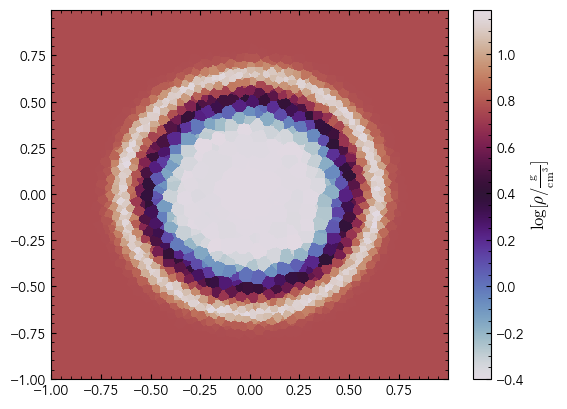

In [5]:
ax, im, data = snap.plots.peek()
# plt.savefig('../reports/figures/sedov.png', dpi=300)
plt.show()

### The first condition

In [6]:
# First condition
condition1 = snap.divV < 0

In [7]:
rho = snap.density
rho_shocked = np.where(condition1, rho, 0*rho)

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


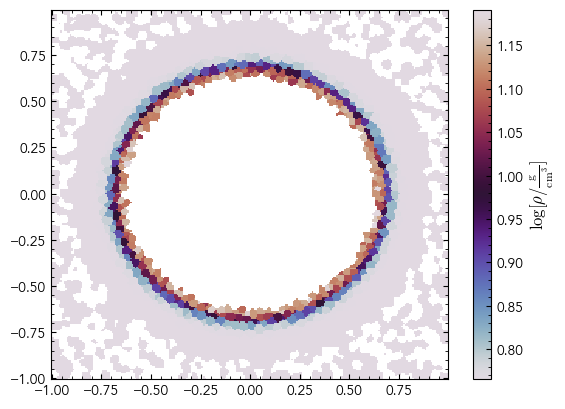

In [8]:
ax, im, sliced_rho = snap.plots.slice(rho_shocked, res=256)
plt.show()

### The second condition
$$
\begin{gather}
T = \frac{\mu m_H}{k_B} \frac{P}{\rho},\\
\partial^i T = \frac{\mu m_H}{k_B} [(\partial^iP)/\rho - P (\partial^i \rho) /\rho^2].
\end{gather}
$$

In [9]:
grad_P = np.stack([snap.DpDx, snap.DpDy, snap.DpDz], axis=-1)
grad_rho = np.stack([snap.DrhoDx, snap.DrhoDy, snap.DrhoDz], axis=-1)
P = snap.P
rho = snap.rho
T = u.mh / u.kb * P / rho # If the code has temperature output, do snap.Temperature

In [10]:
# numpy only broadcasts if we have matching trailing index (e.g., shape (3,10,)
# + shape (10,) works, but (10,3,) + shape (10,), which is what we have here,
# doesn't). So we transpose to (3,10,) to make it work and transpose back to 
# (10,3,) in the end.
grad_T = u.mh / u.kb * (grad_P.T / rho - P * grad_rho.T / rho**2).T

In [11]:
# The second condition
condition2 = np.vecdot(grad_T, grad_P) > 0
np.shape(condition2)

(100000,)

In [12]:
np.sum(condition2) # most of it is true

np.int64(92404)

In [13]:
rho_shocked = np.where(condition1 & condition2, rho, 0*rho)

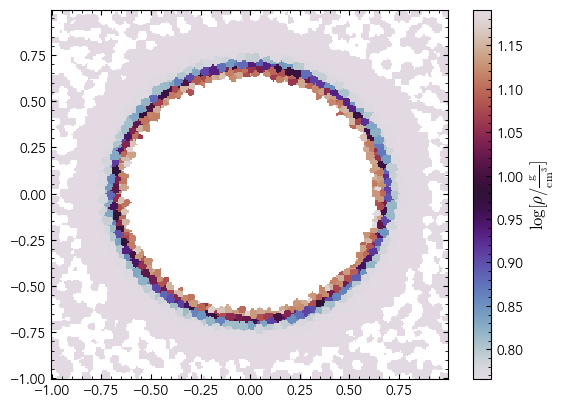

In [14]:
ax, im, sliced_rho = snap.plots.slice(rho_shocked, res=256)
plt.show()

### The third condition

In [15]:
def shock_direction(grad_T):
    """Find the shock direction given temperature gradient.
    d_s = - grad_T / |grad_T|
    """
    norm_grad_T = np.linalg.norm(grad_T, axis=-1, keepdims=True)

    # For small magnitudes, set ds to zero
    ds = - grad_T / norm_grad_T

    if len(np.shape(ds)) > 1:
        ds[norm_grad_T[:,0] < 1e-3 * norm_grad_T.units] = 0
    else:
        if norm_grad_T < 1e-3 * norm_grad_T.units:
            ds *= 0
    # ds = np.where(norm_grad_T < 1e-3, np.zeros_like(grad_T), - grad_T / norm_grad_T)

    return ds

In [16]:
def next_cell_along_ds(kdtree, X, Y, Z, point, ds, step):
    """Find the previous/next point along the shock direction by moving in
    the shock direction by steps of distance `step` each time. Use a negative
    step for the opposite direction.
    """
    ds /= np.linalg.norm(ds, keepdims=True) # normalise ds just to be safe
        
    k = 0           # number of steps
    distance = 0    # distance between point and new_point
    while distance == 0:
        k += 1
        new_point = point + k * step * ds
        d, i  = kdtree.query(new_point)
        new_point = np.array([X[i], Y[i], Z[i]])
        distance = math.dist(point, new_point)

    return i

In [17]:
dev.MT2T1(M=1.3, gamma=5/3), dev.MP2P1(M=1.3, gamma=5/3)

(1.2921782544378697, 1.8624999999999998)

In [18]:
np.log10(dev.MT2T1(M=1.3, gamma=5/3)), np.log10(dev.MP2P1(M=1.3, gamma=5/3))

(np.float64(0.11132242819377774), np.float64(0.27009628142033043))

In [19]:

from scipy.spatial import Voronoi
from collections import defaultdict
import time

# Strip unyt units once — Voronoi and numba both need plain float64
positions_np = np.stack([snap.X.v, snap.Y.v, snap.Z.v], axis=-1)
T_np         = np.asarray(T,         dtype=np.float64)   # temperature [K]
P_np         = np.asarray(snap.P,    dtype=np.float64)   # pressure [code]
rho_np       = np.asarray(snap.rho,  dtype=np.float64)   # density  [code]

# ── Voronoi tessellation ──────────────────────────────────────────────────────
print(f"Building Voronoi tessellation for {len(positions_np):,} cells ...")
t0  = time.perf_counter()
vor = Voronoi(positions_np)

adj = defaultdict(list)
for i, j in vor.ridge_points:
    adj[i].append(j)
    adj[j].append(i)
neighbors = [adj[k] for k in range(len(positions_np))]
t_vor = time.perf_counter() - t0

# ── CSR (Compressed Sparse Row) format for numba ─────────────────────────────
# Python list-of-lists can't enter @njit; CSR arrays can.
sizes        = np.array([len(n) for n in neighbors], dtype=np.int32)
neighbor_ptr = np.zeros(len(neighbors) + 1, dtype=np.int32)
np.cumsum(sizes, out=neighbor_ptr[1:])
neighbor_data = np.array([j for n in neighbors for j in n], dtype=np.int32)

print(f"Done in {t_vor:.2f}s  |  mean neighbours/cell: {sizes.mean():.1f}"
      f"  |  total edges: {len(neighbor_data):,}")


Building Voronoi tessellation for 100,000 cells ...


Done in 4.27s  |  mean neighbours/cell: 14.7  |  total edges: 1,473,724


In [20]:

from numba import njit
import math as _math

# ── next_cell_nb ─────────────────────────────────────────────────────────────

@njit(cache=True)
def next_cell_nb(positions, neighbor_data, neighbor_ptr, current_idx, dx, dy, dz):
    """Walk one Voronoi face in direction (dx,dy,dz) from cell current_idx.

    The Voronoi face between generators xᵢ, xⱼ is the perpendicular bisector
    plane  n = xⱼ-xᵢ.  A ray from xᵢ in direction d̂ hits it at
        t_ij = |n|² / (2 · n·d̂)
    We pick the neighbour with smallest positive t.

    Source: Springel (2010) MNRAS 401 §2; standard ray-plane intersection.

    Returns neighbour index, or -1 if the ray hits the domain boundary.
    """
    xi = positions[current_idx, 0]
    yi = positions[current_idx, 1]
    zi = positions[current_idx, 2]
    norm = _math.sqrt(dx*dx + dy*dy + dz*dz)
    if norm == 0.0:
        return -1
    dx /= norm;  dy /= norm;  dz /= norm
    best_t = _math.inf
    best_j = -1
    for k in range(neighbor_ptr[current_idx], neighbor_ptr[current_idx + 1]):
        j  = neighbor_data[k]
        nx = positions[j, 0] - xi
        ny = positions[j, 1] - yi
        nz = positions[j, 2] - zi
        nd = nx*dx + ny*dy + nz*dz
        if nd <= 0.0:
            continue
        t = (nx*nx + ny*ny + nz*nz) / (2.0 * nd)
        if t < best_t:
            best_t = t
            best_j = j
    return best_j


# ── condition3_nb ─────────────────────────────────────────────────────────────

@njit(cache=True)
def condition3_nb(positions, neighbor_data, neighbor_ptr,
                  i_shock_zone, T_np, P_np, ds_np, DlogT_min, DlogP_min):
    """Condition 3 (Schaal+14) for every candidate cell, fully JIT-compiled.

    ds_np : (N, 3) float64 — shock directions for each cell in i_shock_zone
            (pre-normalised, zero rows are skipped automatically).
    Returns a bool array of length N.
    """
    n = len(i_shock_zone)
    result = np.zeros(n, dtype=np.bool_)
    for k in range(n):
        idx = i_shock_zone[k]
        dx = ds_np[k, 0];  dy = ds_np[k, 1];  dz = ds_np[k, 2]
        if dx == 0.0 and dy == 0.0 and dz == 0.0:
            continue
        i_pre  = next_cell_nb(positions, neighbor_data, neighbor_ptr, idx,  dx,  dy,  dz)
        i_post = next_cell_nb(positions, neighbor_data, neighbor_ptr, idx, -dx, -dy, -dz)
        if i_pre < 0 or i_post < 0:
            continue
        T_pre  = T_np[i_pre];   T_post  = T_np[i_post]
        P_pre  = P_np[i_pre];   P_post  = P_np[i_post]
        if T_pre <= 0.0 or T_post <= 0.0 or P_pre <= 0.0 or P_post <= 0.0:
            continue
        DlogT = _math.log10(T_post) - _math.log10(T_pre)
        DlogP = _math.log10(P_post) - _math.log10(P_pre)
        if DlogT >= DlogT_min and DlogP >= DlogP_min:
            result[k] = True
    return result


# ── _ray_tracer_nb ────────────────────────────────────────────────────────────

@njit(cache=True)
def _ray_tracer_nb(positions, neighbor_data, neighbor_ptr, shock_mask,
                   idx_shock, idx_cell, divV_shock, ds_shock,
                   sign, max_steps):
    """Trace a ray from shock cell idx_cell in direction sign*ds until outside the shock zone.

    sign = +1 → pre-shock (along ds),  sign = -1 → post-shock (against ds).
    Returns the global index of the pre/post-shock cell, or -1 if rejected.
    """
    current_idx = idx_shock[idx_cell]
    dx = sign * ds_shock[idx_cell, 0]
    dy = sign * ds_shock[idx_cell, 1]
    dz = sign * ds_shock[idx_cell, 2]
    norm = _math.sqrt(dx*dx + dy*dy + dz*dz)
    if norm == 0.0:
        return -1
    dx /= norm;  dy /= norm;  dz /= norm
    divV_curr = divV_shock[idx_cell]

    for _ in range(max_steps):
        nxt = next_cell_nb(positions, neighbor_data, neighbor_ptr, current_idx, dx, dy, dz)
        if nxt < 0:
            return -1                                      # domain boundary
        if not shock_mask[nxt]:
            return nxt                                     # exited shock zone

        # Still inside — look up by binary search (idx_shock is sorted)
        pos = np.searchsorted(idx_shock, nxt)
        if pos < len(idx_shock) and idx_shock[pos] == nxt:
            divV_nxt = divV_shock[pos]
            if divV_nxt < divV_curr:
                return -1                                  # unphysical → reject
            dot = dx*ds_shock[pos,0] + dy*ds_shock[pos,1] + dz*ds_shock[pos,2]
            if dot < 0.0:
                return nxt                                 # direction reversed → exit
            divV_curr = divV_nxt
        current_idx = nxt
    return -1                                              # max_steps exceeded


# ── find_shock_surface_nb ─────────────────────────────────────────────────────

@njit(cache=True)
def find_shock_surface_nb(positions, neighbor_data, neighbor_ptr,
                          T_np, P_np, rho_np,
                          shock_mask, idx_shock, divV_shock, ds_shock,
                          gamma, max_steps=500):
    """Full shock-surface finder on the Voronoi graph — fully JIT-compiled.

    All arguments must be plain float64/int64/bool NumPy arrays (no unyt).
    Mach formulas are inlined from Schaal+14 / sf.py (T2T1M, P2P1M, rho2rho1M).
    """
    n = len(idx_shock)
    M_T_out   = np.empty(n, dtype=np.float64)
    M_P_out   = np.empty(n, dtype=np.float64)
    M_rho_out = np.empty(n, dtype=np.float64)
    surf_out  = np.empty(n, dtype=np.int64)
    pre_out   = np.empty(n, dtype=np.int64)
    post_out  = np.empty(n, dtype=np.int64)
    count = 0

    for i in range(n):
        if ds_shock[i, 0] == 0.0 and ds_shock[i, 1] == 0.0 and ds_shock[i, 2] == 0.0:
            continue

        i_post = _ray_tracer_nb(positions, neighbor_data, neighbor_ptr, shock_mask,
                                idx_shock, i, divV_shock, ds_shock, -1, max_steps)
        if i_post < 0:
            continue

        i_pre = _ray_tracer_nb(positions, neighbor_data, neighbor_ptr, shock_mask,
                               idx_shock, i, divV_shock, ds_shock, +1, max_steps)
        if i_pre < 0:
            continue

        T_jump = T_np[i_post] / T_np[i_pre]
        if T_jump < 1.0 or T_np[i_pre] <= 0.0:
            continue

        P_jump   = P_np[i_post]   / P_np[i_pre]
        rho_jump = rho_np[i_post] / rho_np[i_pre]

        # ── Mach from T jump (T2T1M inlined) ───────────────────────────────
        a_T    = 2.0 * gamma * (gamma - 1.0)
        mb_T   = 2.0*gamma - 6.0*gamma + T_jump*(gamma + 1.0)**2 + 1.0
        disc_T = mb_T*mb_T + 8.0*a_T*(gamma - 1.0)
        M_T    = _math.sqrt(max((mb_T + _math.sqrt(max(disc_T, 0.0))) / (2.0*a_T), 0.0))

        # ── Mach from P jump (P2P1M inlined) ───────────────────────────────
        M2_P = (P_jump*(gamma + 1.0) + gamma - 1.0) / (2.0*gamma)
        M_P  = _math.sqrt(max(M2_P, 0.0))

        # ── Mach from rho jump (rho2rho1M inlined) ─────────────────────────
        dR    = gamma + 1.0 - rho_jump*(gamma - 1.0)
        M_rho = _math.sqrt(2.0*rho_jump / dR) if dR > 0.0 else 0.0

        M_T_out[count]   = M_T
        M_P_out[count]   = M_P
        M_rho_out[count] = M_rho
        surf_out[count]  = i
        pre_out[count]   = i_pre
        post_out[count]  = i_post
        count += 1

    return (M_T_out[:count], M_P_out[:count], M_rho_out[:count],
            surf_out[:count], pre_out[:count], post_out[:count])


print("Numba functions defined. JIT compiles on first call (cached → instant on restart).")


Numba functions defined. JIT compiles on first call (cached → instant on restart).


In [21]:
from scipy.spatial import KDTree

X = snap.X;  Y = snap.Y;  Z = snap.Z
coords = np.stack([X, Y, Z], axis=-1)
kdtree = KDTree(coords)              # kept for the old-approach comparison cells below

i_all        = np.arange(len(snap), dtype=np.int64)
i_shock_zone = i_all[condition1 & condition2]

# Vectorised shock directions for all cond-1 & cond-2 candidates (strips unyt)
ds_cond3 = np.ascontiguousarray(
    shock_direction(grad_T[i_shock_zone]), dtype=np.float64)   # shape (N, 3)

print(f"Running condition 3 (Voronoi + numba) on {len(i_shock_zone):,} candidates ...")
t0 = time.perf_counter()
cond3_mask = condition3_nb(
    positions_np, neighbor_data, neighbor_ptr,
    np.ascontiguousarray(i_shock_zone, dtype=np.int64),
    T_np, P_np, ds_cond3, 0.11, 0.27)
t_cond3_new = time.perf_counter() - t0

condition3 = np.full(len(snap), False)
condition3[i_shock_zone[cond3_mask]] = True
print(f"Found {np.sum(condition3):,} shock-zone cells  in {t_cond3_new:.2f}s"
      f"  (includes first-call JIT compile; next run will be faster)")


Running condition 3 (Voronoi + numba) on 59,802 candidates ...


Found 16,976 shock-zone cells  in 3.19s  (includes first-call JIT compile; next run will be faster)


In [22]:
np.sum(condition3)

np.int64(16976)

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


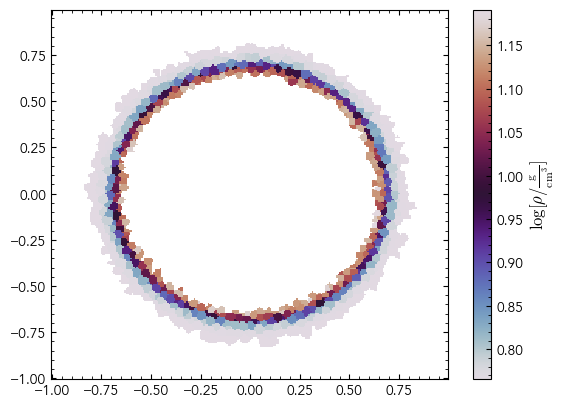

In [23]:
rho_shocked = np.where(condition1 & condition2 & condition3, snap.rho, 0*richio.units.system["density"]) # hmm just to look nice, in fact condition3 alone is enough...
ax, im, sliced_rho = snap.plots.slice(rho_shocked, res=256)
plt.show()

## Step 2: shock surface
This involves a "ray tracing" step

In [24]:
def T2T1M(T2_T1, gamma):
    """ Find mach number from the temperature jump (T2_T1). """
    a = 2 * gamma * (gamma - 1)
    minusb = gamma * 2 - 6 * gamma + T2_T1 * (gamma + 1)**2 + 1
    M2 = (minusb + np.sqrt(minusb**2 + 8 * a * (gamma - 1))) / (2 * a)
    return np.sqrt(M2)

def P2P1M(P2_P1, gamma):
    """ Find mach number from the pressure jump (P2_P1). """
    M2 = (P2_P1 * (gamma + 1) + gamma - 1) / (2 * gamma)
    return np.sqrt(M2)

def rho2rho1M(rho2_rho1, gamma):
    """ Find mach number from the density jump (rho2_rho1). """
    M2 = 2 * rho2_rho1 / (gamma + 1 - rho2_rho1 * (gamma - 1))
    return np.sqrt(M2)

In [25]:
def ray_tracer(kdtree, X, Y, Z, shock_mask, x_shock, y_shock, z_shock, 
               idx_shock, idx_cell, divV_shock, ds_shock, direction, gamma=5/3):
    """Trace along shock direction until exiting shock zone.
    
    Parameters
    -----------
    kdtree : scipy.spatial.KDTree
        KDTree of all simulation cells.
    X, Y, Z : arrays
        All cell center coordinates.
    shock_mask : bool array
        Boolean mask of shock cells.
    x_shock, y_shock, z_shock : arrays
        Shock zone cell coordinates.
    idx_shock : array
        Global indices of shock zone cells.
    idx_cell : int
        Index within shock zone array.
    divV_shock : array
        Divergence field in shock zone.
    ds_shock : array
        Shock direction field in shock zone.
    direction : str
        'pre' or 'post' shock region.
    gamma : float
        Adiabatic index.
    
    Returns
    -----------
    i_final : int or False
        Global index of pre/post-shock cell, or False if ray rejected.
    """
    x_pt = x_shock[idx_cell]
    y_pt = y_shock[idx_cell]
    z_pt = z_shock[idx_cell]
    point = np.array([x_pt, y_pt, z_pt])
    
    divV_pt = divV_shock[idx_cell]
    ds_pt = np.array(ds_shock[idx_cell])
    
    # Estimate step size from nearest neighbors # TODO: use volume
    distances, _ = kdtree.query(point, k=10)
    step_size = np.median(distances[1:])  # exclude self
    
    # Ray trace until exiting shock zone
    in_shock = True
    step_sign = -1 if direction == 'post' else 1
    
    while in_shock:
        i_tree = next_cell_along_ds(kdtree, X, Y, Z, point, ds_pt, step_sign * step_size)
        in_shock = shock_mask[i_tree]
        
        if in_shock:
            # Find this cell in shock zone array
            idx_in_shock = np.argmin(np.abs(i_tree - idx_shock))
            divV_next = divV_shock[idx_in_shock]
            ds_next = ds_shock[idx_in_shock]
            
            # Reject if divergence decreases (unphysical ray)
            if divV_next < divV_pt:
                return False
            
            # Stop if shock direction reverses
            if np.dot(ds_pt, ds_next) < 0:
                in_shock = False
        
        point = np.array([X[i_tree], Y[i_tree], Z[i_tree]])
    
    return i_tree

def find_shock_surface(kdtree, X, Y, Z, T, P, rho, shock_mask, 
                       x_shock, y_shock, z_shock, idx_shock, divV_shock, ds_shock, gamma=5/3):
    """Find shock surface cells and their pre/post-shock counterparts.
    
    Parameters
    -----------
    kdtree : scipy.spatial.KDTree
        KDTree of all cells.
    X, Y, Z : arrays
        Cell coordinates.
    T, P, rho : arrays
        Temperature, pressure, density fields.
    shock_mask : bool array
        Shock zone mask.
    x_shock, y_shock, z_shock : arrays
        Shock zone coordinates.
    idx_shock : array
        Global indices of shock cells.
    divV_shock : array
        Divergence in shock zone.
    ds_shock : array
        Shock direction in shock zone.
    gamma : float
        Adiabatic index.
    
    Returns
    -----------
    M_T, M_P, M_rho : arrays
        Mach numbers from T, P, rho jumps.
    idx_surf : array
        Indices of surface cells (in shock zone array).
    idx_pre, idx_post : arrays
        Global indices of pre/post-shock cells.
    """
    M_T = []
    M_P = []
    M_rho = []
    idx_surf = []
    idx_pre = []
    idx_post = []
    
    for i in range(len(x_shock)):
        # x_pt, y_pt, z_pt = x_shock[i], y_shock[i], z_shock[i]
        # # Spatial domain restrictions (adjust as needed)
        # if x_pt < 7 or x_pt > 20 or np.abs(y_pt) > 25 or np.abs(z_pt) > 1:
        #     continue
        
        if np.linalg.norm(ds_shock[i]) == 0:
            continue
        
        # Ray trace to post-shock
        i_post = ray_tracer(kdtree, X, Y, Z, shock_mask, x_shock, y_shock, z_shock,
                            idx_shock, i, divV_shock, ds_shock, direction='post', gamma=gamma)
        if i_post is False:
            continue
        
        T_post = T[i_post]
        
        # Ray trace to pre-shock
        i_pre = ray_tracer(kdtree, X, Y, Z, shock_mask, x_shock, y_shock, z_shock,
                           idx_shock, i, divV_shock, ds_shock, direction='pre', gamma=gamma)
        if i_pre is False:
            continue
        
        T_pre = T[i_pre]
        T_jump = T_post / T_pre
        
        # Only accept if temperature increases (physical shock)
        if T_jump < 1:
            continue
        
        # Record surface cell
        idx_surf.append(i)
        idx_pre.append(i_pre)
        idx_post.append(i_post)
        
        # Calculate Mach numbers from jumps
        P_pre, P_post = P[i_pre], P[i_post]
        P_jump = P_post / P_pre
        
        rho_pre, rho_post = rho[i_pre], rho[i_post]
        rho_jump = rho_post / rho_pre
        
        M_T.append(T2T1M(T_jump, gamma))
        M_P.append(P2P1M(P_jump, gamma))
        M_rho.append(rho2rho1M(rho_jump, gamma))
    
    return np.array(M_T), np.array(M_P), np.array(M_rho), \
        np.array(idx_surf), np.array(idx_pre), np.array(idx_post)

In [26]:
# Step 2: Find shock surface
# ...existing code...

# Build KDTree for efficient nearest-neighbor queries
coords = np.stack([X, Y, Z], axis=-1)
kdtree = KDTree(coords)

# Prepare shock zone data
i_shock = i_all[condition1 & condition2 & condition3]
x_shock = X[i_shock]
y_shock = Y[i_shock]
z_shock = Z[i_shock]
divV_shock = snap.divV[i_shock]
ds_shock = shock_direction(grad_T[i_shock])

# Find shock surface
M_T, M_P, M_rho, idx_surf, idx_pre, idx_post = find_shock_surface(
    kdtree, X, Y, Z, T, snap.P, snap.rho, 
    condition1 & condition2 & condition3,
    x_shock, y_shock, z_shock, i_shock, divV_shock, ds_shock,
    gamma=5/3
)

print(f"Found {len(idx_surf)} shock surface cells")
print(f"Mach numbers - T: {M_T.mean():.2f}, P: {M_P.mean():.2f}, rho: {M_rho.mean():.2f}")

Found 4788 shock surface cells
Mach numbers - T: 217.86, P: 145.71, rho: 1.62


In [27]:
i_shock_surface_orig = i_shock[idx_surf] # convert index of shockzone to index of all

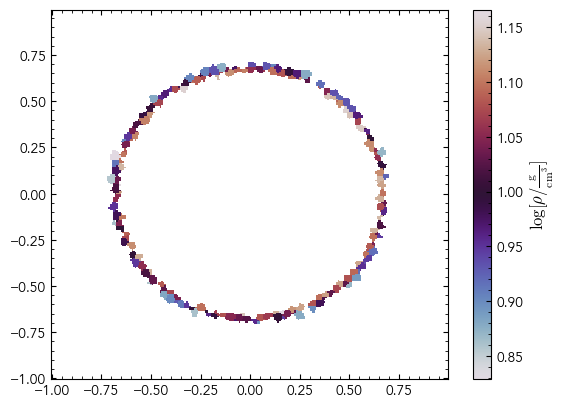

In [28]:
rho_shocked = np.zeros_like(snap.rho)
rho_shocked[i_shock_surface_orig] = snap.rho[i_shock_surface_orig]
ax, im, sliced_rho = snap.plots.slice(rho_shocked, res=256)
plt.show()


---
## Old vs New: Voronoi traversal — timing and accuracy comparison

**OLD** — `next_cell_along_ds`: steps in increments of `0.8 × ∛volume` and queries
a KDTree each step until a different cell is found. Multiple queries per cell crossing,
step size is heuristic and can misfire in anisotropic regions.

**NEW** — `next_cell_voronoi`: the Voronoi face between generators **xᵢ** and **xⱼ**
is the perpendicular bisector plane (normal **n** = **xⱼ**−**xᵢ**).
A ray **xᵢ** + t **d̂** crosses it at **t = |n|² / (2 n·d̂)**.
Pick the neighbour with the smallest positive t → exact one-cell step, zero step-size
tuning, zero KDTree queries after the initial adjacency build.


In [29]:

import time

# Re-run OLD condition 3 with explicit timing
# (uses variables already in scope: kdtree, coords, i_shock_zone, grad_T, snap, T)
print("Timing OLD condition 3 (this is the slow step) ...")
t0 = time.perf_counter()
condition3_old = np.full(len(snap), False)

for idx in i_shock_zone:
    ds_i  = shock_direction(grad_T[idx])
    step  = 0.8 * np.cbrt(snap.volume[idx])
    point = coords[idx]
    if np.linalg.norm(ds_i) > 0 * u.Dimensionless:
        i_pre_t  = next_cell_along_ds(kdtree, X, Y, Z, point, ds_i,  step)
        i_post_t = next_cell_along_ds(kdtree, X, Y, Z, point, ds_i, -step)
        DlogT = np.log10(T[i_post_t])      - np.log10(T[i_pre_t])
        DlogP = np.log10(snap.P[i_post_t]) - np.log10(snap.P[i_pre_t])
        if (DlogT >= 0.11) & (DlogP >= 0.27):
            condition3_old[idx] = True

t_cond3_old = time.perf_counter() - t0
print(f"  OLD: {np.sum(condition3_old)} shock cells  in {t_cond3_old:.1f} s")
print(f"  NEW: {np.sum(condition3)} shock cells  in {t_cond3_new:.2f} s  (Voronoi+numba)")

# Re-run OLD shock surface with timing
i_shock_old    = i_all[condition1 & condition2 & condition3_old]
x_shock_old    = X[i_shock_old]; y_shock_old = Y[i_shock_old]; z_shock_old = Z[i_shock_old]
divV_shock_old = snap.divV[i_shock_old]
ds_shock_old   = shock_direction(grad_T[i_shock_old])

print(f"\nTiming OLD shock surface ({len(i_shock_old)} shock-zone cells) ...")
t0 = time.perf_counter()
M_T_old, M_P_old, M_rho_old, idx_surf_old, idx_pre_old, idx_post_old = find_shock_surface(
    kdtree, X, Y, Z, T, snap.P, snap.rho,
    condition1 & condition2 & condition3_old,
    x_shock_old, y_shock_old, z_shock_old, i_shock_old, divV_shock_old, ds_shock_old,
    gamma=5/3)
t_surf_old = time.perf_counter() - t0
print(f"  {len(idx_surf_old)} surf cells  in {t_surf_old:.1f} s")


Timing OLD condition 3 (this is the slow step) ...
  OLD: 17248 shock cells  in 306.6 s
  NEW: 16976 shock cells  in 3.19 s  (Voronoi+numba)

Timing OLD shock surface (17248 shock-zone cells) ...
  4788 surf cells  in 4.2 s


In [30]:

# Voronoi tessellation + CSR arrays were built before condition 3 above.
# Reusing positions_np, neighbor_data, neighbor_ptr, T_np, P_np, rho_np, t_vor.
print(f"Voronoi already built in {t_vor:.2f}s  |  mean neighbours: {sizes.mean():.1f}")
print("T_np / P_np / rho_np already stripped of unyt units.")


Voronoi already built in 4.27s  |  mean neighbours: 14.7
T_np / P_np / rho_np already stripped of unyt units.


In [31]:

def next_cell_voronoi(positions_np, neighbors, current_idx, d):
    """Walk one Voronoi face crossing in direction d from cell current_idx.

    The Voronoi face between generators xᵢ, xⱼ is the perpendicular bisector
    plane of segment xᵢ xⱼ:
        normal  n = xⱼ − xᵢ
        through m = (xᵢ + xⱼ) / 2
    A ray starting at xᵢ in direction d̂ hits this plane at
        t_ij = |n|² / (2 · n · d̂)
    and the next cell is the neighbour with the smallest positive t.

    Source: Springel (2010), MNRAS 401, §2 (AREPO); standard ray–plane
    intersection applied to Voronoi bisector planes.
    """
    xi    = positions_np[current_idx]
    d_hat = d / np.linalg.norm(d)
    best_t, best_j = np.inf, -1
    for j in neighbors[current_idx]:
        n  = positions_np[j] - xi
        nd = np.dot(n, d_hat)
        if nd <= 0:           # face behind or parallel
            continue
        t = np.dot(n, n) / (2.0 * nd)
        if t < best_t:
            best_t, best_j = t, j
    return best_j             # -1 means ray hit domain boundary


def ray_tracer_vor(positions_np, neighbors, shock_mask, idx_shock_sorted,
                   idx_cell, divV_shock, ds_shock, direction, max_steps=500):
    """Trace a ray from shock cell idx_cell along ±ds until leaving the shock zone.

    Uses exact perpendicular-bisector face intersections — no step size, no KDTree.
    idx_shock_sorted must be a sorted integer array (it is when built from np.arange masking).
    """
    current_idx  = int(idx_shock_sorted[idx_cell])
    dir_vec      = ds_shock[idx_cell].copy()
    if direction == 'post':
        dir_vec = -dir_vec
    norm = np.linalg.norm(dir_vec)
    if norm == 0:
        return False
    dir_vec /= norm
    divV_current = divV_shock[idx_cell]

    for _ in range(max_steps):
        next_idx = next_cell_voronoi(positions_np, neighbors, current_idx, dir_vec)
        if next_idx < 0:                       # hit domain boundary
            return False
        if not shock_mask[next_idx]:
            return next_idx                    # found pre/post-shock cell

        # Still inside shock zone — look up by binary search (O(log N_shock))
        pos = np.searchsorted(idx_shock_sorted, next_idx)
        if pos < len(idx_shock_sorted) and idx_shock_sorted[pos] == next_idx:
            divV_next = divV_shock[pos]
            ds_next   = ds_shock[pos]
            if divV_next < divV_current:       # unphysical → reject
                return False
            if np.dot(dir_vec, ds_next) < 0:  # shock direction reversed → exit
                return next_idx
            divV_current = divV_next
        current_idx = next_idx

    return False                               # exceeded max_steps


def find_shock_surface_vor(positions_np, neighbors, T_np, P_np, rho_np,
                           shock_mask, idx_shock, divV_shock, ds_shock, gamma=5/3):
    """find_shock_surface implemented with exact Voronoi cell traversal.

    All array arguments (T_np, P_np, rho_np, divV_shock, ds_shock) must be
    plain float64 NumPy arrays (no unyt units).
    """
    M_T, M_P, M_rho           = [], [], []
    idx_surf, i_pre_l, i_post_l = [], [], []

    for i in range(len(idx_shock)):
        if np.linalg.norm(ds_shock[i]) == 0:
            continue

        i_post = ray_tracer_vor(positions_np, neighbors, shock_mask, idx_shock,
                                i, divV_shock, ds_shock, 'post')
        if i_post is False:
            continue

        i_pre = ray_tracer_vor(positions_np, neighbors, shock_mask, idx_shock,
                               i, divV_shock, ds_shock, 'pre')
        if i_pre is False:
            continue

        T_jump = T_np[i_post] / T_np[i_pre]
        if T_jump < 1:
            continue

        P_jump   = P_np[i_post]   / P_np[i_pre]
        rho_jump = rho_np[i_post] / rho_np[i_pre]

        idx_surf.append(i)
        i_pre_l.append(i_pre)
        i_post_l.append(i_post)
        M_T.append(T2T1M(T_jump, gamma))
        M_P.append(P2P1M(P_jump, gamma))
        M_rho.append(rho2rho1M(rho_jump, gamma))

    return (np.array(M_T), np.array(M_P), np.array(M_rho),
            np.array(idx_surf), np.array(i_pre_l), np.array(i_post_l))


In [32]:

# ── NEW shock surface (numba) ─────────────────────────────────────────────────
# condition3 / condition3_new are the SAME array (built by the numba cell above).
shock_mask_new = np.asarray(condition1 & condition2 & condition3, dtype=np.bool_)
i_shock_new    = np.ascontiguousarray(i_all[shock_mask_new], dtype=np.int64)
divV_shock_new = np.ascontiguousarray(snap.divV.v[i_shock_new], dtype=np.float64)
ds_shock_new   = np.ascontiguousarray(
    shock_direction(grad_T[i_shock_new]), dtype=np.float64)      # (N, 3)

print(f"Running NEW shock surface (numba, {len(i_shock_new):,} shock-zone cells)...")
t0 = time.perf_counter()
M_T_new, M_P_new, M_rho_new, idx_surf_new, idx_pre_new, idx_post_new = \
    find_shock_surface_nb(
        positions_np, neighbor_data, neighbor_ptr, T_np, P_np, rho_np,
        shock_mask_new, i_shock_new, divV_shock_new, ds_shock_new, 5/3)
t_surf_new = time.perf_counter() - t0

# condition3_new alias for compare cell
condition3_new = condition3

print(f"  NEW: {len(idx_surf_new)} surf cells  in {t_surf_new:.2f}s")
print(f"  OLD: {len(idx_surf_old)} surf cells  in {t_surf_old:.1f}s")
print(f"  Surf speedup: {t_surf_old/t_surf_new:.1f}×")
print(f"  Mach (NEW) — T: {M_T_new.mean():.2f},  P: {M_P_new.mean():.2f},  ρ: {M_rho_new.mean():.2f}")
print(f"  Mach (OLD) — T: {M_T_old.mean():.2f},  P: {M_P_old.mean():.2f},  ρ: {M_rho_old.mean():.2f}")


Running NEW shock surface (numba, 16,976 shock-zone cells)...
  NEW: 3598 surf cells  in 1.00s
  OLD: 4788 surf cells  in 4.2s
  Surf speedup: 4.1×
  Mach (NEW) — T: 187.08,  P: 141.30,  ρ: 2.02
  Mach (OLD) — T: 219.08,  P: 145.41,  ρ: 1.60


Condition-3 Jaccard  (old∩new)/(old∪new) = 0.9816
Shock-surface Jaccard               = 0.7511
  OLD only : 1191
  NEW only : 1
  BOTH     : 3597


/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


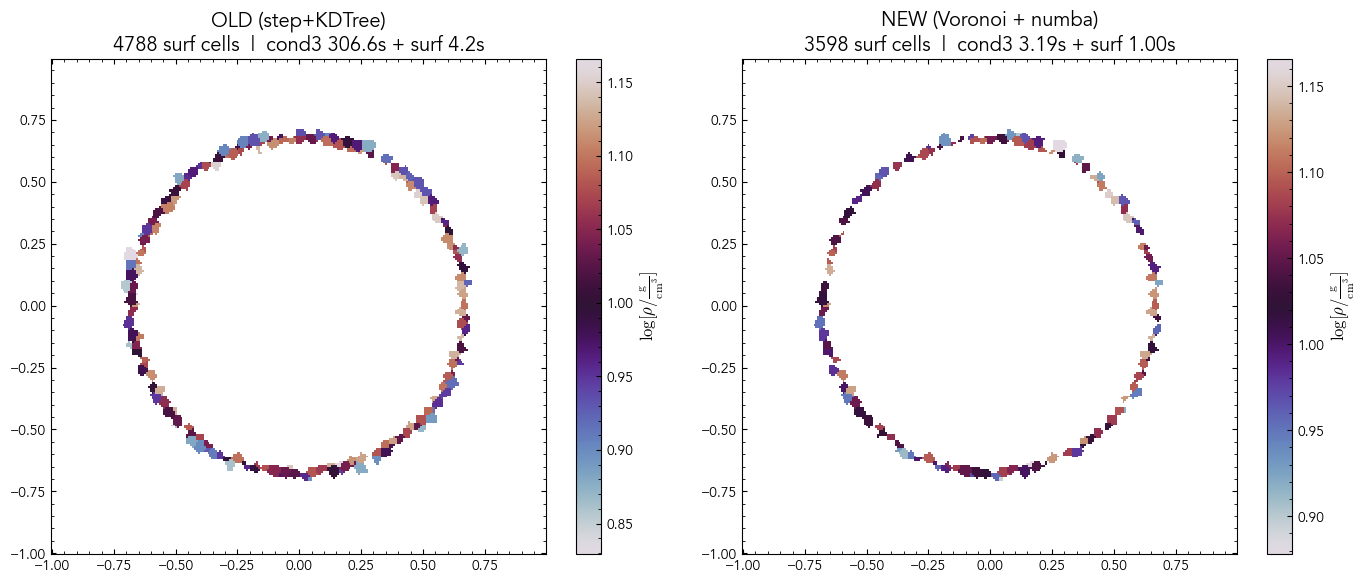

/tmp/ipykernel_3288413/1516540829.py:47: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Avenir.
  plt.tight_layout()
/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Avenir.
  fig.canvas.print_figure(bytes_io, **kw)


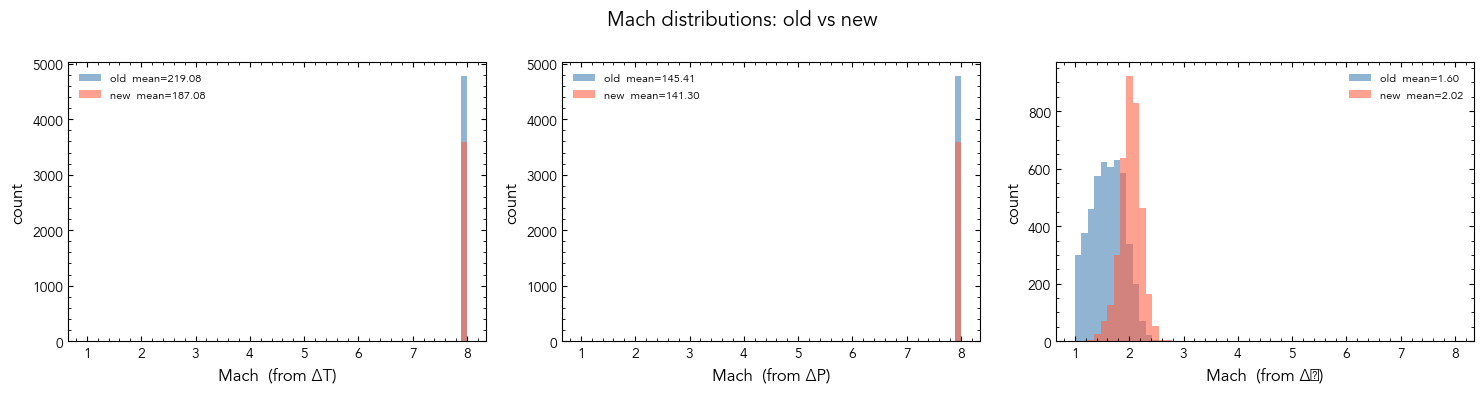

In [ ]:

# ── COMPARE ─────────────────────────────────────────────────────────────────
old_c3_set = set(np.where(condition3_old)[0].tolist())
new_c3_set = set(np.where(condition3_new)[0].tolist())
jaccard_c3 = len(old_c3_set & new_c3_set) / len(old_c3_set | new_c3_set)
print(f"Condition-3 Jaccard  (old∩new)/(old∪new) = {jaccard_c3:.4f}")

surf_old  = set(i_shock_old[idx_surf_old].tolist())
surf_new  = set(i_shock_new[idx_surf_new].tolist())
jaccard_s = len(surf_old & surf_new) / len(surf_old | surf_new)
print(f"Shock-surface Jaccard               = {jaccard_s:.4f}")
print(f"  OLD only : {len(surf_old - surf_new)}")
print(f"  NEW only : {len(surf_new - surf_old)}")
print(f"  BOTH     : {len(surf_old & surf_new)}")

# ── Side-by-side density maps ─────────────────────────────────────────────────
rho_surf_old = np.zeros_like(snap.rho)
rho_surf_old[i_shock_old[idx_surf_old]] = snap.rho[i_shock_old[idx_surf_old]]
rho_surf_new = np.zeros_like(snap.rho)
rho_surf_new[i_shock_new[idx_surf_new]] = snap.rho[i_shock_new[idx_surf_new]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
snap.plots.slice(rho_surf_old, res=256, ax=axes[0])
axes[0].set_title(
    f"OLD (step+KDTree)\n{len(surf_old)} surf cells  |  cond3 {t_cond3_old:.1f}s + surf {t_surf_old:.1f}s")
snap.plots.slice(rho_surf_new, res=256, ax=axes[1])
axes[1].set_title(
    f"NEW (Voronoi + numba)\n{len(surf_new)} surf cells  |  cond3 {t_cond3_new:.2f}s + surf {t_surf_new:.2f}s")
plt.tight_layout()
plt.show()

# ── Mach-number distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = np.linspace(1, 8, 60)
for ax, Mo, Mn, lbl in zip(
        axes,
        [M_T_old, M_P_old, M_rho_old],
        [M_T_new, M_P_new, M_rho_new],
        ['T', 'P', 'rho']):
    ax.hist(np.clip(Mo, 1, 8), bins=bins, alpha=0.6,
            label=f'old  mean={np.mean(Mo):.2f}', color='steelblue')
    ax.hist(np.clip(Mn, 1, 8), bins=bins, alpha=0.6,
            label=f'new  mean={np.mean(Mn):.2f}', color='tomato')
    ax.set_xlabel(f'Mach  (from Δ{lbl})')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.suptitle('Mach distributions: old vs new')
plt.tight_layout()
plt.show()
